Import the required libraries

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util

Load the training dataset

In [2]:
train_df = pd.read_csv("train.csv")

print("Training set shape:", train_df.shape)
train_df.head()

Training set shape: (2700, 2)


,Question,Answer
0,How can blood donation centers collaborate wit...,Collaboration may involve implementing evidenc...
1,What strategies can be employed to address the...,Strategies to address stigma and discriminatio...
2,What role do community events or festivals pla...,Community events or festivals provide opportun...
3,How can blood donation centers collaborate wit...,Blood donation centers can partner with transp...
4,How do blood donation centers ensure the quali...,Blood donation centers ensure the quality and ...


Load the embedding model

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encode all training questions

In [4]:
train_questions = train_df["Question"].tolist()
train_answers = train_df["Answer"].tolist()

question_embeddings = model.encode(train_questions, convert_to_tensor=True)

print("Number of encoded questions:", len(train_questions))
print("Embedding shape:", question_embeddings.shape)

Number of encoded questions: 2700
Embedding shape: torch.Size([2700, 384])


Define the retrieval function

In [5]:
def retrieve_answer(user_query, questions, answers, embeddings, model):
    query_embedding = model.encode(user_query, convert_to_tensor=True)
    
    similarities = util.cos_sim(query_embedding, embeddings)[0]
    best_match_index = similarities.argmax().item()
    best_score = similarities[best_match_index].item()
    
    matched_question = questions[best_match_index]
    retrieved_answer = answers[best_match_index]
    
    return {
        "user_query": user_query,
        "matched_question": matched_question,
        "retrieved_answer": retrieved_answer,
        "similarity_score": best_score
    }

Test the chatbot with a sample question

In [6]:
result = retrieve_answer(
    "Can I donate blood if I have a cold?",
    train_questions,
    train_answers,
    question_embeddings,
    model
)

print("User Query:", result["user_query"])
print("Matched Question:", result["matched_question"])
print("Retrieved Answer:", result["retrieved_answer"])
print("Similarity Score:", result["similarity_score"])

User Query: Can I donate blood if I have a cold?
Matched Question: Can individuals who have recently received vaccinations donate plasma and blood?
Retrieved Answer: In most cases, individuals who have recently received vaccinations are eligible to donate plasma and blood, provided they are feeling well and have no adverse reactions to the vaccines. Donation centers may have specific guidelines regarding deferral periods for certain vaccines.
Similarity Score: 0.6659107208251953


Try a few more sample questions

In [7]:
sample_questions = [
    "Is it safe to donate blood?",
    "How often can I donate blood?",
    "Can I donate blood after taking medicine?",
    "Will donating blood make me weak?"
]

for q in sample_questions:
    result = retrieve_answer(q, train_questions, train_answers, question_embeddings, model)
    print("\nUser Query:", result["user_query"])
    print("Matched Question:", result["matched_question"])
    print("Retrieved Answer:", result["retrieved_answer"])
    print("Similarity Score:", round(result["similarity_score"], 4))
    print("-" * 80)


User Query: Is it safe to donate blood?
Matched Question: How do blood donation centers address donor concerns regarding the safety and efficacy of donated blood products?
Retrieved Answer: Blood donation centers address donor concerns regarding the safety and efficacy of donated blood products by providing transparent information about screening and testing procedures, ensuring adherence to strict quality control standards, and offering opportunities for donors to ask questions and seek reassurance.
Similarity Score: 0.7576
--------------------------------------------------------------------------------

User Query: How often can I donate blood?
Matched Question: How often can individuals donate plasma and blood?
Retrieved Answer: The frequency of plasma and blood donation varies depending on local regulations and donor eligibility. In most cases, donors can donate plasma every 28 days and whole blood every 56 days.
Similarity Score: 0.8619
-------------------------------------------

Loading the validation set

In [8]:
validation_df = pd.read_csv("validation.csv")

print("Validation set shape:", validation_df.shape)
validation_df.head()

Validation set shape: (338, 2)


,Question,Answer
0,What impact do intergenerational donation even...,"Intergenerational donation events, such as fam..."
1,How do blood drive hosts collaborate with acad...,Blood drive hosts collaborate with academic in...
2,What factors contribute to disparities in bloo...,Disparities in blood donation rates among diff...
3,What role can celebrity endorsements and partn...,Celebrity endorsements and influencer partners...
4,How does blood donation support families of pa...,Blood donation supports families of patients b...


Run retrieval on all validation questions

In [9]:
validation_questions = validation_df["Question"].tolist()
validation_answers = validation_df["Answer"].tolist()

results = []

for i, (true_question, true_answer) in enumerate(zip(validation_questions, validation_answers)):
    output = retrieve_answer(
        true_question,
        train_questions,
        train_answers,
        question_embeddings,
        model
    )
    
    results.append({
        "validation_question": true_question,
        "expected_answer": true_answer,
        "matched_question": output["matched_question"],
        "retrieved_answer": output["retrieved_answer"],
        "similarity_score": output["similarity_score"],
        "exact_answer_match": true_answer.strip().lower() == output["retrieved_answer"].strip().lower()
    })

results_df = pd.DataFrame(results)

print("Validation retrieval completed.")
print("Number of evaluated questions:", len(results_df))
results_df.head()

Validation retrieval completed.
Number of evaluated questions: 338


,validation_question,expected_answer,matched_question,retrieved_answer,similarity_score,exact_answer_match
0,What impact do intergenerational donation even...,"Intergenerational donation events, such as fam...",How can donating blood promote intergeneration...,Donating blood can promote intergenerational g...,0.743672,False
1,How do blood drive hosts collaborate with acad...,Blood drive hosts collaborate with academic in...,How do blood drive hosts collaborate with tech...,Blood drive hosts collaborate with technology ...,0.883122,False
2,What factors contribute to disparities in bloo...,Disparities in blood donation rates among diff...,What factors contribute to disparities in bloo...,Disparities in blood donation rates among raci...,0.948832,False
3,What role can celebrity endorsements and partn...,Celebrity endorsements and influencer partners...,What role can celebrity endorsements and influ...,Celebrity endorsements and influencer partners...,0.986526,False
4,How does blood donation support families of pa...,Blood donation supports families of patients b...,What role do medical professionals play in sup...,Medical professionals play a critical role in ...,0.822303,False


Overall baseline evaluation summary

In [10]:
exact_match_accuracy = results_df["exact_answer_match"].mean()

print("Exact Answer Match Accuracy:", round(exact_match_accuracy * 100, 2), "%")
print("\nSimilarity Score Summary:")
print(results_df["similarity_score"].describe())

Exact Answer Match Accuracy: 0.0 %

Similarity Score Summary:
count    338.000000
mean       0.892562
std        0.061476
min        0.677430
25%        0.861228
50%        0.900296
75%        0.936842
max        0.998680
Name: similarity_score, dtype: float64


View the best-performing examples

In [11]:
best_cases = results_df.sort_values("similarity_score", ascending=False).head(10)

best_cases[[
    "validation_question",
    "matched_question",
    "similarity_score",
    "exact_answer_match"
]]

,validation_question,matched_question,similarity_score,exact_answer_match
203,How do blood donation organizations collaborat...,How do blood donation organizations collaborat...,0.998680,False
143,How do blood transfusion services ensure the s...,How do blood transfusion services in Tanzania ...,0.998292,False
8,"How do social determinants of health, such as ...","How do social determinants of health, such as ...",0.997322,False
146,How can blood donation facilitation programs c...,How can blood donation facilitation programs c...,0.994418,False
237,How can blood donation centers leverage social...,How can blood donation centers leverage social...,0.992337,False
210,What challenges can arise in promoting blood d...,What are the challenges of promoting blood don...,0.991900,False
89,How do blood donation centers ensure the ethic...,How do blood donation centers ensure the ethic...,0.990763,False
213,What role can community-based organizations an...,What role can community-based organizations an...,0.990192,False
157,How do blood donation centers ensure the safet...,How do blood donation centers ensure the safet...,0.989549,False
288,How can blood donation facilitation programs a...,How can blood donation facilitation programs a...,0.987689,False


View the weakest-performing examples

In [12]:
worst_cases = results_df.sort_values("similarity_score", ascending=True).head(20)

worst_cases[[
    "validation_question",
    "matched_question",
    "retrieved_answer",
    "similarity_score",
    "exact_answer_match"
]]

,validation_question,matched_question,retrieved_answer,similarity_score,exact_answer_match
33,What factors do bottom-up plans consider in es...,What are the key factors that determine the su...,Key factors include the availability and relia...,0.677430,False
319,What innovative approaches are being explored ...,What techniques are being utilized to enhance ...,Computer modeling techniques and simulation mo...,0.680668,False
46,What factors influenced the timing and frequen...,In what manner were blood transfusions adminis...,Blood transfusions were administered intraveno...,0.710674,False
219,What factors contribute to demographic dispari...,In what ways might donor demographics affect t...,"Demographic factors such as age, socioeconomic...",0.714773,False
131,How can individuals benefit from quitting smok...,How can blood donation support individuals wit...,Blood donation supports individuals with chron...,0.718077,False
10,How has the World Health Organization addresse...,What initiatives has Tanzania's national blood...,Tanzania's national blood supplier has impleme...,0.727678,False
215,What impact do blood drives have on local heal...,How do blood drive hosts address concerns rela...,Blood drive hosts implement proactive recruitm...,0.734027,False
331,What role do donor-centered policies and pract...,"What role do donor feedback mechanisms, such a...","Donor feedback mechanisms, such as surveys or ...",0.736362,False
0,What impact do intergenerational donation even...,How can donating blood promote intergeneration...,Donating blood can promote intergenerational g...,0.743672,False
19,What are the potential implications of donor d...,How do donor deferral policies impact donation...,Donor deferral policies can impact donation ra...,0.744285,False


Inspect exact mismatches only

In [13]:
mismatches = results_df[results_df["exact_answer_match"] == False]

print("Number of mismatches:", len(mismatches))
mismatches[[
    "validation_question",
    "expected_answer",
    "matched_question",
    "retrieved_answer",
    "similarity_score"
]].head(20)

Number of mismatches: 338


,validation_question,expected_answer,matched_question,retrieved_answer,similarity_score
0,What impact do intergenerational donation even...,"Intergenerational donation events, such as fam...",How can donating blood promote intergeneration...,Donating blood can promote intergenerational g...,0.743672
1,How do blood drive hosts collaborate with acad...,Blood drive hosts collaborate with academic in...,How do blood drive hosts collaborate with tech...,Blood drive hosts collaborate with technology ...,0.883122
2,What factors contribute to disparities in bloo...,Disparities in blood donation rates among diff...,What factors contribute to disparities in bloo...,Disparities in blood donation rates among raci...,0.948832
3,What role can celebrity endorsements and partn...,Celebrity endorsements and influencer partners...,What role can celebrity endorsements and influ...,Celebrity endorsements and influencer partners...,0.986526
4,How does blood donation support families of pa...,Blood donation supports families of patients b...,What role do medical professionals play in sup...,Medical professionals play a critical role in ...,0.822303
5,What role do blood donation organizations play...,Blood donation organizations play a critical r...,What role do blood donation organizations play...,Blood donation organizations advocate for poli...,0.961286
6,How do blood transfusion services manage the l...,Blood transfusion services utilize specialized...,How do blood transfusion services in Africa ma...,Blood transfusion services employ specialized ...,0.858440
7,How can blood centers leverage digital analyti...,Blood centers can leverage digital analytics a...,How can blood centers leverage data analytics ...,Blood centers can leverage data analytics and ...,0.813954
8,"How do social determinants of health, such as ...","Social determinants of health, including incom...","How do social determinants of health, such as ...","Social determinants of health, including incom...",0.997322
9,What post-donation care measures does the WHO ...,The WHO recommends providing blood donors with...,What measures can blood donation centers take ...,Blood donation centers can enhance donor satis...,0.822984


Similarity score distribution

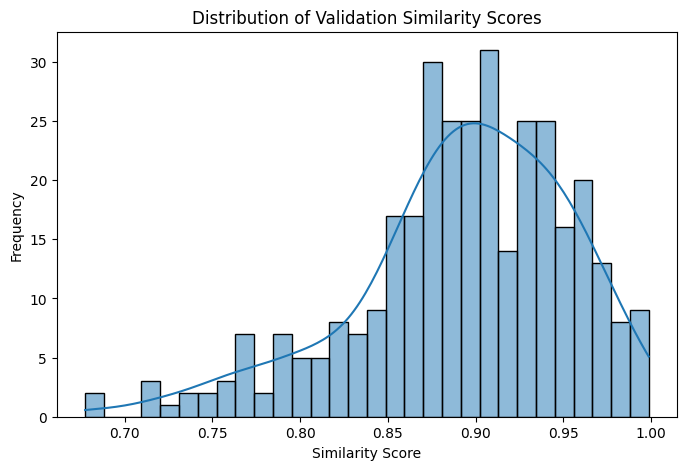

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(results_df["similarity_score"], bins=30, kde=True)
plt.title("Distribution of Validation Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

Save evaluation results for documentation

In [15]:
results_df.to_csv("validation_results_baseline.csv", index=False)
best_cases.to_csv("validation_best_cases.csv", index=False)
worst_cases.to_csv("validation_worst_cases.csv", index=False)
mismatches.to_csv("validation_mismatches.csv", index=False)

print("Saved validation evaluation files.")

Saved validation evaluation files.


Quick interpretation table for reporting

In [16]:
summary = {
    "Validation samples": len(results_df),
    "Exact answer match accuracy (%)": round(results_df["exact_answer_match"].mean() * 100, 2),
    "Average similarity score": round(results_df["similarity_score"].mean(), 4),
    "Minimum similarity score": round(results_df["similarity_score"].min(), 4),
    "Maximum similarity score": round(results_df["similarity_score"].max(), 4)
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Validation samples,338.0000
1,Exact answer match accuracy (%),0.0000
2,Average similarity score,0.8926
3,Minimum similarity score,0.6774
4,Maximum similarity score,0.9987


Count retrieval  matches

In [17]:
threshold = 0.85

high_confidence_matches = results_df[
    results_df["similarity_score"] >= threshold
]

accuracy_semantic = len(high_confidence_matches) / len(results_df)

print("Semantic Retrieval Accuracy (>= 0.85 similarity):",
      round(accuracy_semantic * 100, 2), "%")

Semantic Retrieval Accuracy (>= 0.85 similarity): 81.07 %


In [18]:
threshold = 0.90

very_high_confidence_matches = results_df[
    results_df["similarity_score"] >= threshold
]

accuracy_strict = len(very_high_confidence_matches) / len(results_df)

print("Strict Semantic Retrieval Accuracy (>= 0.90 similarity):",
      round(accuracy_strict * 100, 2), "%")

Strict Semantic Retrieval Accuracy (>= 0.90 similarity): 51.18 %
